# ST_Buffer(geom,distance,num_vertices=36)

Create a buffer of a given geometry.

In [8]:
import geofunctions as S
import geopandas as gp
import pyspark.sql.functions as F

In [14]:
data = [(10.0, 10.0, 100.0, 20.0, 120.0, 0.0)]

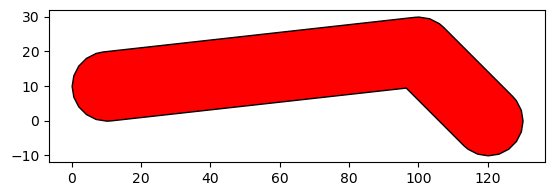

In [20]:
pdf = (
    spark.createDataFrame(
        data, "x1 double,y1 double," "x2 double,y2 double," "x3 double,y3 double"
    )
    .select(S.st_polyline2(F.array("x1", "y1", "x2", "y2", "x3", "y3")).alias("geom"))
    .select(S.st_buffer("geom", 10.0, num_vertices=18).alias("geometry"))
    .toPandas()
)
pdf.geometry = gp.GeoSeries.from_wkb(pdf.geometry)
gdf = gp.GeoDataFrame(pdf)
_ = gdf.plot(linewidth=1, edgecolor="black", color="red")